# 📐 Regression Evaluation Metrics
## A Complete Guide to Measuring, Diagnosing, and Reporting Model Performance

---

Building a model is only half the work. The other half — understanding *how well* it performs, *where* it fails, and *whether* it's trustworthy — requires rigorous evaluation. This notebook teaches you:

- **What each metric measures** (and what it doesn't)
- **When to choose each metric** for different business problems
- **Residual analysis** to diagnose assumption violations
- **Learning curves** to detect bias vs variance problems
- **How to create a comprehensive evaluation report**

We continue using the **insurance.csv** dataset, comparing models trained in the previous notebook.

---

In [2]:
from google.colab import files

files.upload()

Saving insurance.csv to insurance.csv


{'insurance.csv': b'age,sex,bmi,children,smoker,region,charges\r\n19,female,27.9,0,yes,southwest,16884.924\r\n18,male,33.77,1,no,southeast,1725.5523\r\n28,male,33,3,no,southeast,4449.462\r\n33,male,22.705,0,no,northwest,21984.47061\r\n32,male,28.88,0,no,northwest,3866.8552\r\n31,female,25.74,0,no,southeast,3756.6216\r\n46,female,33.44,1,no,southeast,8240.5896\r\n37,female,27.74,3,no,northwest,7281.5056\r\n37,male,29.83,2,no,northeast,6406.4107\r\n60,female,25.84,0,no,northwest,28923.13692\r\n25,male,26.22,0,no,northeast,2721.3208\r\n62,female,26.29,0,yes,southeast,27808.7251\r\n23,male,34.4,0,no,southwest,1826.843\r\n56,female,39.82,0,no,southeast,11090.7178\r\n27,male,42.13,0,yes,southeast,39611.7577\r\n19,male,24.6,1,no,southwest,1837.237\r\n52,female,30.78,1,no,northeast,10797.3362\r\n23,male,23.845,0,no,northeast,2395.17155\r\n56,male,40.3,0,no,southwest,10602.385\r\n30,male,35.3,0,yes,southwest,36837.467\r\n60,female,36.005,0,no,northeast,13228.84695\r\n30,female,32.4,1,no,southwe

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']

print("✅ Imports complete!")

✅ Imports complete!


In [4]:
# Load and preprocess data (same pipeline as treebased_algorithms notebook)
df = pd.read_csv('insurance.csv')

df_encoded = df.copy()
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df_encoded[col] = le.fit_transform(df[col])

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train our models
models = {
    'Linear Regression':    LinearRegression(),
    'Decision Tree':        DecisionTreeRegressor(max_depth=4, random_state=42),
    'Random Forest':        RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42),
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(f"✅ Trained: {name}")

print(f"\nTest set size: {len(y_test)} samples")
print(f"Target range: ${y_test.min():,.0f} – ${y_test.max():,.0f}")

✅ Trained: Linear Regression
✅ Trained: Decision Tree
✅ Trained: Random Forest
✅ Trained: Gradient Boosting

Test set size: 268 samples
Target range: $1,132 – $63,770


---

# 📏 Part 1: Regression Metrics — Theory and Intuition

## 1.1 MAE — Mean Absolute Error

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

MAE measures the **average absolute difference** between actual and predicted values. Every error is weighted equally, regardless of magnitude.

**Intuition:** If MAE = \$2,500, on average your predictions are off by \$2,500 — sometimes over, sometimes under.

**Advantages:**
- Easy to interpret (same units as the target)
- Robust to outliers — large errors are not disproportionately penalized

**Disadvantages:**
- Not differentiable at zero (optimization challenges)
- Doesn't distinguish between many small errors vs few large errors

**Use MAE when:** The cost of errors is proportional to their size, and you want to be robust to occasional large errors (outliers).

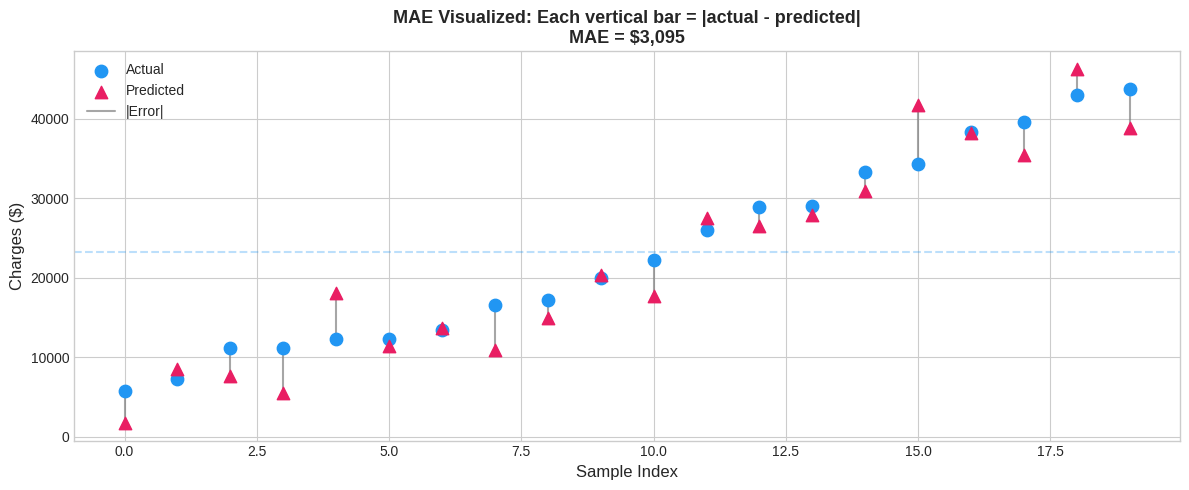

In [ ]:
# MAE Explained Visually
np.random.seed(42)
n_demo = 20
y_actual  = np.sort(np.random.uniform(5000, 45000, n_demo))
y_pred_demo = y_actual + np.random.normal(0, 4000, n_demo)

errors_demo = y_actual - y_pred_demo
mae_demo = np.mean(np.abs(errors_demo))

plt.figure(figsize=(12, 5))
plt.scatter(range(n_demo), y_actual,    label='Actual',    color=COLORS[0], zorder=5, s=80)
plt.scatter(range(n_demo), y_pred_demo, label='Predicted', color=COLORS[3], zorder=5, s=80, marker='^')
for i in range(n_demo):
    plt.plot([i, i], [y_actual[i], y_pred_demo[i]],
             color='gray', linewidth=1.5, alpha=0.7,
             label='|Error|' if i == 0 else None)

plt.axhline(y=np.mean(y_actual), color=COLORS[0], linestyle='--', alpha=0.3)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Charges ($)', fontsize=12)
plt.title(f'MAE Visualized: Each vertical bar = |actual - predicted|\nMAE = ${mae_demo:,.0f}',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('mae_visual.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Calculate MAE for all models
print("📊 MAE — Mean Absolute Error:")
print("  Interpretation: Average dollar amount predictions are off by\n")
for name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    pct_of_mean = mae / y_test.mean() * 100
    print(f"  {name:<22}: MAE = ${mae:,.0f}  ({pct_of_mean:.1f}% of mean charge)")

## 1.2 MSE and RMSE — Mean Squared Error and Root Mean Squared Error

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

$$\text{RMSE} = \sqrt{\text{MSE}}$$

MSE **squares** each error before averaging. This means **large errors are penalized much more heavily** than small ones.

RMSE restores the units (dollars, not dollars²), making it more interpretable — but it still emphasizes large errors.

**Intuition:** RMSE = the typical prediction error, weighted toward larger mistakes. If RMSE > MAE significantly, you have some large outlier errors.

**Advantages:**
- Differentiable → easier to optimize mathematically
- Heavily penalizes large errors → use when big mistakes are very costly

**Disadvantages:**
- Sensitive to outliers
- Harder to interpret than MAE (especially MSE)

**Use RMSE when:** Large prediction errors are significantly worse than small ones (e.g., predicting hospital readmission risk where missing a high-risk patient is catastrophic).

In [ ]:
# MSE vs MAE: Sensitivity to outliers
errors_base    = np.array([100, -200, 150, -80, 120, -90, 200, -130, 110, -160])
errors_outlier = errors_base.copy()
errors_outlier[-1] = -5000  # Add one large outlier

def compute_metrics(errors):
    mae  = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    return mae, rmse

mae_base, rmse_base = compute_metrics(errors_base)
mae_out,  rmse_out  = compute_metrics(errors_outlier)

print("Outlier Sensitivity Comparison:")
print(f"\nWithout outlier:  MAE=${mae_base:.0f}   RMSE=${rmse_base:.0f}")
print(f"With outlier (-$5000): MAE=${mae_out:.0f}  RMSE=${rmse_out:.0f}")
print(f"\nChange in MAE:  +{mae_out/mae_base:.1f}x")
print(f"Change in RMSE: +{rmse_out/rmse_base:.1f}x  ← RMSE is much more affected!")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('MSE/RMSE vs MAE: Outlier Sensitivity', fontsize=13, fontweight='bold')

for ax, errors, title in zip(axes,
                              [errors_base, errors_outlier],
                              ['Without Outlier', 'With One Large Outlier (-$5000)']):
    mae, rmse = compute_metrics(errors)
    ax.bar(range(len(errors)), np.abs(errors), color=COLORS[0], alpha=0.7, label='|Error|')
    ax.axhline(mae,  color=COLORS[3], linewidth=2, linestyle='--', label=f'MAE=${mae:.0f}')
    ax.axhline(rmse, color=COLORS[2], linewidth=2, linestyle='-',  label=f'RMSE=${rmse:.0f}')
    ax.set_title(title)
    ax.set_xlabel('Sample')
    ax.set_ylabel('|Error| ($)')
    ax.legend()

plt.tight_layout()
plt.savefig('mse_mae_outlier.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# RMSE for all models
print("📊 MSE and RMSE:")
print("  RMSE is in same units as target; larger penalties for big errors\n")
for name, y_pred in predictions.items():
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"  {name:<22}: RMSE = ${rmse:,.0f}   (MSE = {mse:,.0f})")

## 1.3 R² — Coefficient of Determination

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2} = 1 - \frac{SS_{res}}{SS_{tot}}$$

R² measures **how much of the target variance your model explains** compared to the baseline of just predicting the mean.

- **R² = 1.0** → Perfect predictions — model explains all variance
- **R² = 0.0** → Model is no better than predicting the mean every time
- **R² < 0.0** → Model is *worse* than predicting the mean (possible!)

**Intuition:** R² = 0.87 means your model explains 87% of the variation in insurance charges. The remaining 13% is unexplained by your features.

**Advantages:**
- Scale-independent (works across different problems)
- Intuitive percentage interpretation

**Disadvantages:**
- Always increases when you add more features (use Adjusted R² for feature selection)
- A high R² doesn't mean the model is well-calibrated or assumptions are met
- Can be misleading for non-linear relationships

In [ ]:
# Visualize what R² measures
rf_pred = predictions['Random Forest']
y_mean_line = np.full_like(y_test, y_test.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('R² = 1 − SS_res / SS_tot: What It Measures', fontsize=13, fontweight='bold')

# Left: baseline model (predict mean)
ss_tot = np.sum((y_test - y_test.mean())**2)
axes[0].scatter(range(len(y_test)), y_test, s=15, alpha=0.5, color=COLORS[0], label='Actual')
axes[0].axhline(y_test.mean(), color=COLORS[3], linewidth=2, label=f'Mean = ${y_test.mean():,.0f}')
for i, (actual, mean_val) in enumerate(zip(y_test, y_mean_line)):
    axes[0].plot([i, i], [actual, mean_val], color='gray', alpha=0.3, linewidth=0.8)
axes[0].set_title(f'Baseline Model (always predict mean)\nSS_tot = {ss_tot:,.0f}   R²=0.0')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Charges ($)')
axes[0].legend()

# Right: our model
ss_res = np.sum((y_test.values - rf_pred)**2)
r2 = 1 - ss_res/ss_tot
axes[1].scatter(range(len(y_test)), y_test, s=15, alpha=0.5, color=COLORS[0], label='Actual')
axes[1].scatter(range(len(y_test)), rf_pred, s=15, alpha=0.5, color=COLORS[1], label='Predicted')
for i, (actual, pred) in enumerate(zip(y_test, rf_pred)):
    axes[1].plot([i, i], [actual, pred], color='gray', alpha=0.3, linewidth=0.8)
axes[1].set_title(f'Random Forest Predictions\nSS_res = {ss_res:,.0f}   R²={r2:.3f}')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Charges ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig('r2_visual.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nExplained: SS_res/SS_tot = {ss_res/ss_tot:.3f}")
print(f"So R² = 1 − {ss_res/ss_tot:.3f} = {r2:.3f}")
print(f"The Random Forest explains {r2*100:.1f}% of variance in insurance charges.")

In [ ]:
# R² for all models
print("📊 R² — Coefficient of Determination:")
print("  Proportion of target variance explained by the model\n")
for name, y_pred in predictions.items():
    r2 = r2_score(y_test, y_pred)
    explained_pct = r2 * 100
    print(f"  {name:<22}: R² = {r2:.4f}  ({explained_pct:.1f}% of variance explained)")

## 1.4 When to Use Which Metric

| Business Context | Best Metric | Reason |
|-----------------|-------------|--------|
| Predict insurance premiums fairly | **MAE** | Outlier-robust; dollar errors treated equally |
| Detect rare catastrophic costs | **RMSE** | Penalizes large errors more |
| Compare models across datasets | **R²** | Scale-independent |
| Check if adding features helps | **Adjusted R²** | Penalizes unnecessary features |
| Percentage error interpretation | **MAPE** | When relative errors matter |
| Medical cost predictions | **MAE + R²** | Interpretable + normalized |
| Financial forecasting | **RMSE** | Large errors are disproportionately bad |

In [ ]:
# MAPE — Mean Absolute Percentage Error (bonus metric)
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error — useful for relative error interpretation."""
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Adjusted R²
def adjusted_r2(y_true, y_pred, n_features):
    """Penalizes adding features that don't meaningfully improve the model."""
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

print("📊 All Metrics Side-by-Side:")
print(f"{'Model':<22} {'MAE':>8} {'RMSE':>8} {'R²':>7} {'Adj R²':>8} {'MAPE %':>8}")
print("-" * 67)
for name, y_pred in predictions.items():
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    adj  = adjusted_r2(y_test.values, y_pred, X.shape[1])
    mape_val = mape(y_test.values, y_pred)
    print(f"{name:<22} ${mae:>7,.0f} ${rmse:>7,.0f} {r2:>7.4f} {adj:>8.4f} {mape_val:>7.1f}%")

---

# 🔍 Part 2: Residual Analysis

Metrics like R² and MAE tell you *how much* error exists. Residual analysis tells you *what kind* of error it is.

**Residual** = Actual − Predicted = $y_i - \hat{y}_i$

For a well-fitting regression model, residuals should:
1. **Be centered around zero** — no systematic over/under-prediction
2. **Be homoscedastic** — equal variance across all predicted values
3. **Be roughly normally distributed** — for valid statistical inference
4. **Be independent** — no patterns across samples

Violations of these assumptions suggest the model is missing important structure in the data.

In [ ]:
# Comprehensive Residual Analysis for all models
fig, axes = plt.subplots(4, 4, figsize=(20, 18))
fig.suptitle('Residual Analysis — All Models', fontsize=16, fontweight='bold')

model_names = list(predictions.keys())
col_titles  = ['Residuals vs Fitted', 'Residual Distribution', 'Q-Q Plot', 'Scale-Location']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontweight='bold', fontsize=12, pad=10)

for row, (name, y_pred) in enumerate(predictions.items()):
    residuals = y_test.values - y_pred
    color = COLORS[row]

    # Plot 1: Residuals vs Fitted (checks homoscedasticity)
    ax = axes[row, 0]
    ax.scatter(y_pred, residuals, alpha=0.4, s=15, color=color)
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Fitted Values ($)')
    ax.set_ylabel(f'{name}\nResiduals ($)', fontsize=9)
    # Add smooth trend line
    z = np.polyfit(y_pred, residuals, 2)
    p = np.poly1d(z)
    x_line = np.linspace(y_pred.min(), y_pred.max(), 100)
    ax.plot(x_line, p(x_line), 'red', linewidth=2, alpha=0.8)

    # Plot 2: Residual Histogram (checks normality)
    ax = axes[row, 1]
    ax.hist(residuals, bins=35, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(0, color='black', linewidth=2, linestyle='--')
    ax.axvline(np.mean(residuals), color='red', linewidth=2, label=f'Mean={np.mean(residuals):,.0f}')
    ax.set_xlabel('Residual ($)')
    ax.legend(fontsize=8)

    # Plot 3: Q-Q Plot (checks normality formally)
    ax = axes[row, 2]
    (osm, osr), (slope, intercept, r) = stats.probplot(residuals)
    ax.scatter(osm, osr, alpha=0.4, s=15, color=color)
    x_qq = np.array([osm.min(), osm.max()])
    ax.plot(x_qq, slope * x_qq + intercept, 'r-', linewidth=2)
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.text(0.05, 0.9, f'R²={r**2:.3f}', transform=ax.transAxes, fontsize=9)

    # Plot 4: Scale-Location (sqrt of |standardized residuals| vs fitted)
    ax = axes[row, 3]
    std_res = residuals / residuals.std()
    ax.scatter(y_pred, np.sqrt(np.abs(std_res)), alpha=0.4, s=15, color=color)
    ax.set_xlabel('Fitted Values ($)')
    ax.set_ylabel('√|Std. Residuals|')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📖 How to interpret each plot:")
print("  Col 1 (Residuals vs Fitted):  Points should scatter randomly around 0. Red curve = trend.")
print("     → If fan-shaped: heteroscedasticity (variance grows with fitted values)")
print("  Col 2 (Residual Histogram):   Should be roughly bell-shaped, centered at 0")
print("  Col 3 (Q-Q Plot):             Points should follow the red line. Tails deviating = non-normal")
print("  Col 4 (Scale-Location):       Should be flat. Upward trend = increasing error variance")

In [ ]:
# Statistical Normality Tests on Residuals
print("📊 Normality Tests on Residuals (Shapiro-Wilk):")
print("  p > 0.05 → cannot reject normality at 5% significance level\n")
for name, y_pred in predictions.items():
    residuals = y_test.values - y_pred
    # Use a sample for Shapiro-Wilk (max 5000 samples)
    sample = np.random.choice(residuals, size=min(len(residuals), 250), replace=False)
    stat, p = stats.shapiro(sample)
    normal = "✅ Approximately Normal" if p > 0.05 else "❌ Non-Normal"
    skewness = stats.skew(residuals)
    kurtosis = stats.kurtosis(residuals)
    print(f"  {name:<22}: W={stat:.4f}, p={p:.4f}  {normal}")
    print(f"    Skewness={skewness:.3f}  Kurtosis={kurtosis:.3f}")

In [ ]:
# Deep dive: Gradient Boosting residuals — where does the model struggle?
gb_pred = predictions['Gradient Boosting']
gb_residuals = y_test.values - gb_pred
gb_pct_error = (gb_residuals / y_test.values) * 100

# Create a DataFrame for analysis
analysis_df = X_test.copy()
analysis_df['actual']    = y_test.values
analysis_df['predicted'] = gb_pred
analysis_df['residual']  = gb_residuals
analysis_df['pct_error'] = gb_pct_error
analysis_df['smoker_lbl'] = df.loc[X_test.index, 'smoker'].values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Gradient Boosting: Where Does the Model Struggle?', fontsize=13, fontweight='bold')

# Error by actual charge level
bins = pd.cut(analysis_df['actual'], bins=5)
binned = analysis_df.groupby(bins, observed=True)['residual'].agg(['mean', 'std'])
binned.plot(kind='bar', y='mean', yerr='std', ax=axes[0], color=COLORS[0], capsize=4)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Mean Residual by Actual Charge Bucket')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Mean Residual ($)')
axes[0].tick_params(axis='x', rotation=30)

# Error by smoker status
smoker_errors = analysis_df.groupby('smoker_lbl')['residual'].agg(['mean', 'median', 'std'])
smoker_errors[['mean', 'median']].plot(kind='bar', ax=axes[1], color=[COLORS[1], COLORS[3]])
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Mean vs Median Residual by Smoker')
axes[1].set_xlabel('Smoker Status')
axes[1].set_ylabel('Residual ($)')
axes[1].tick_params(axis='x', rotation=0)

# Percentage error distribution
axes[2].hist(gb_pct_error, bins=40, color=COLORS[4], edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='black', linewidth=2, linestyle='--')
axes[2].axvline(np.mean(gb_pct_error), color='red', linewidth=2, label=f'Mean={np.mean(gb_pct_error):.1f}%')
axes[2].set_title('Percentage Error Distribution')
axes[2].set_xlabel('% Error (Actual − Predicted) / Actual × 100')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('residual_deep_dive.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nWorst over-predictions (model predicts too high):")
print(analysis_df.nlargest(3, 'residual')[['actual', 'predicted', 'residual', 'smoker_lbl']].to_string())
print(f"\nWorst under-predictions (model predicts too low):")
print(analysis_df.nsmallest(3, 'residual')[['actual', 'predicted', 'residual', 'smoker_lbl']].to_string())

---

# 📈 Part 3: Learning Curves — Diagnosing Bias and Variance

## The Bias-Variance Tradeoff

Every model's prediction error can be decomposed into three components:

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

- **Bias:** Error from wrong assumptions in the model (underfitting). A linear model applied to a highly non-linear problem has high bias.
- **Variance:** Error from sensitivity to training data fluctuations (overfitting). A very deep decision tree has high variance.
- **Irreducible Noise:** The natural randomness in the data that no model can eliminate.

**Learning curves** plot training and validation performance as the training set size grows. They are one of the most powerful diagnostic tools available:

| Pattern | Diagnosis | Fix |
|---------|-----------|-----|
| Large gap between train/val | High Variance (overfitting) | More data, regularization, simpler model |
| Both curves low & close | High Bias (underfitting) | More features, complex model, reduce regularization |
| Val curve plateaus below threshold | Data limitation | Feature engineering, better data |
| Both curves converge high | Good fit! | Celebrate 🎉 |

In [ ]:
# Learning Curves for all four models
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Learning Curves: Bias-Variance Diagnosis for All Models', fontsize=15, fontweight='bold')

lc_models = {
    'Linear Regression':  LinearRegression(),
    'Decision Tree':      DecisionTreeRegressor(max_depth=4, random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
}

for ax, (name, model), color in zip(axes.flatten(), lc_models.items(), COLORS):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 12),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color=COLORS[0], linewidth=2.5, label='Train Score', markersize=7)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=COLORS[0])
    ax.plot(train_sizes, val_mean,   's-', color=color,     linewidth=2.5, label='CV Val Score', markersize=7)
    ax.fill_between(train_sizes, val_mean - val_std,   val_mean + val_std,   alpha=0.15, color=color)

    # Annotate the final gap
    final_gap = train_mean[-1] - val_mean[-1]
    ax.annotate(f'Gap={final_gap:.3f}', xy=(train_sizes[-1], (train_mean[-1]+val_mean[-1])/2),
                fontsize=10, color='darkred', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

    ax.set_xlabel('Training Examples', fontsize=11)
    ax.set_ylabel('R² Score', fontsize=11)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylim(-0.1, 1.05)
    ax.legend(fontsize=10)
    ax.axhline(0, color='gray', linewidth=1, linestyle=':')

plt.tight_layout()
plt.savefig('learning_curves_all.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n📖 Diagnosis summary:")
print("  Linear Regression:  Converges quickly but at moderate R² → moderate bias, correct model family?")
print("  Decision Tree:      Train score >0.9, val lower → slight variance (overfitting)")
print("  Random Forest:      Good val score, smaller gap → reduced variance via bagging")
print("  Gradient Boosting:  Best val score, moderate gap → strongest model, some variance")

📊 5-Fold Cross-Validation R² Scores (more reliable than single train/test split):
  Uses all data for validation across 5 rounds — reduces evaluation variance

  Linear Regression     : [0.761 0.708 0.778 0.734 0.755] → Mean=0.7473 ± 0.0240
  Decision Tree         : [0.874 0.785 0.883 0.837 0.867] → Mean=0.8491 ± 0.0356
  Random Forest         : [0.855 0.773 0.872 0.829 0.851] → Mean=0.8360 ± 0.0343
  Gradient Boosting     : [0.866 0.793 0.893 0.846 0.854] → Mean=0.8504 ± 0.0329


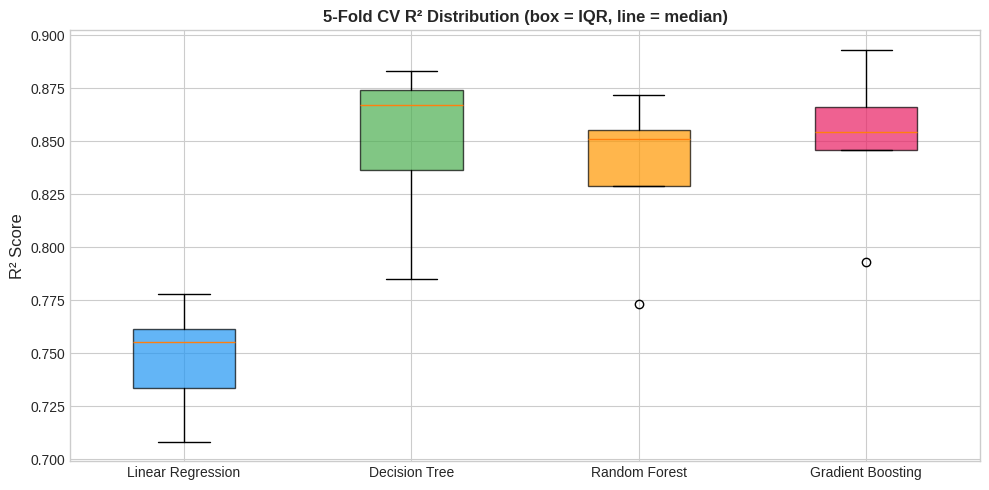

In [ ]:
# Cross-Validation: More Reliable Performance Estimates
print("📊 5-Fold Cross-Validation R² Scores (more reliable than single train/test split):")
print("  Uses all data for validation across 5 rounds — reduces evaluation variance\n")

cv_results = {}
for name, model in lc_models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:<22}: {scores.round(3)} → Mean={scores.mean():.4f} ± {scores.std():.4f}")

# Visual comparison
plt.figure(figsize=(10, 5))
data_for_box = [cv_results[name] for name in lc_models]
bp = plt.boxplot(data_for_box, labels=list(lc_models.keys()), patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
plt.ylabel('R² Score', fontsize=12)
plt.title('5-Fold CV R² Distribution (box = IQR, line = median)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---

# 📋 Part 4: Comprehensive Evaluation Report

A production-ready model evaluation should document all metrics, residual characteristics, and provide clear recommendations.

In [ ]:
def comprehensive_eval_report(model_name, y_true, y_pred, n_features, cv_scores=None):
    """
    Generate a comprehensive evaluation report for a regression model.

    Parameters:
    -----------
    model_name  : str    — Name of the model
    y_true      : array — Actual target values
    y_pred      : array — Predicted values
    n_features  : int   — Number of features used
    cv_scores   : array — Cross-validation scores (optional)
    """
    residuals = np.array(y_true) - np.array(y_pred)
    n = len(y_true)

    # Core metrics
    mae   = mean_absolute_error(y_true, y_pred)
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    r2    = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1-r2) * (n-1) / (n-n_features-1)
    mape_val = np.mean(np.abs(residuals / y_true)) * 100

    # Residual characteristics
    skewness = stats.skew(residuals)
    kurt     = stats.kurtosis(residuals)
    _, p_norm = stats.shapiro(np.random.choice(residuals, size=min(250, len(residuals)), replace=False))

    # Print formatted report
    print("=" * 65)
    print(f"  EVALUATION REPORT — {model_name.upper()}")
    print("=" * 65)
    print(f"  Samples:        {n}")
    print(f"  Features:       {n_features}")
    print()
    print("  ─── Prediction Metrics ─────────────────────────────")
    print(f"  MAE:            ${mae:>10,.2f}  (avg $ error)")
    print(f"  RMSE:           ${rmse:>10,.2f}  (penalizes large errors)")
    print(f"  R²:             {r2:>11.4f}  ({r2*100:.1f}% variance explained)")
    print(f"  Adjusted R²:    {adj_r2:>11.4f}  (penalized for #features)")
    print(f"  MAPE:           {mape_val:>10.2f}%  (avg % error)")
    print()
    print("  ─── Residual Statistics ─────────────────────────────")
    print(f"  Mean residual:  ${np.mean(residuals):>10,.2f}  (bias; ideally 0)")
    print(f"  Std residual:   ${np.std(residuals):>10,.2f}")
    print(f"  Min residual:   ${np.min(residuals):>10,.2f}")
    print(f"  Max residual:   ${np.max(residuals):>10,.2f}")
    print(f"  Skewness:       {skewness:>11.4f}  (|>1| = significant skew)")
    print(f"  Kurtosis:       {kurt:>11.4f}  (>3 = heavy tails)")
    normal_str = "✅ Not rejected" if p_norm > 0.05 else "❌ Rejected"
    print(f"  Normality (SW): p={p_norm:.4f}  {normal_str}")

    if cv_scores is not None:
        print()
        print("  ─── Cross-Validation ─────────────────────────────")
        print(f"  CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        print(f"  Scores:         {np.round(cv_scores, 4)}")

    print()
    print("  ─── Assessment ──────────────────────────────────────")
    # Diagnose bias/variance from CV if available
    if r2 > 0.85:
        print("  ✅ Strong model fit (R² > 0.85)")
    elif r2 > 0.7:
        print("  ⚠️  Moderate fit (0.7 < R² ≤ 0.85) — consider tuning")
    else:
        print("  ❌ Weak fit (R² ≤ 0.7) — reconsider model or features")

    bias = abs(np.mean(residuals))
    if bias < mae * 0.1:
        print("  ✅ Low systematic bias (mean residual ≈ 0)")
    else:
        print(f"  ⚠️  Systematic bias detected: mean residual = ${np.mean(residuals):,.0f}")
    print("=" * 65)
    print()


# Generate reports for all models
for name, y_pred in predictions.items():
    cv = cv_results.get(name, None)
    comprehensive_eval_report(name, y_test.values, y_pred, X.shape[1], cv)

In [ ]:
# Final Dashboard: Best model detailed analysis
best_name = 'Gradient Boosting'
best_pred = predictions[best_name]
best_residuals = y_test.values - best_pred

fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(f'📊 Full Evaluation Dashboard — {best_name}\nInsurance Charges Prediction',
             fontsize=15, fontweight='bold')

# 1. Actual vs Predicted
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.scatter(y_test, best_pred, alpha=0.5, s=20, color=COLORS[2])
lim = max(y_test.max(), best_pred.max())
ax1.plot([0,lim],[0,lim],'k--',linewidth=2,label='Perfect Fit')
ax1.set_xlabel('Actual Charges ($)')
ax1.set_ylabel('Predicted Charges ($)')
ax1.set_title(f'Actual vs Predicted | R²={r2_score(y_test, best_pred):.4f}')
ax1.legend()

# 2. Metrics Summary
ax2 = fig.add_subplot(gs[0, 2])
metrics = {
    'MAE': f'${mean_absolute_error(y_test, best_pred):,.0f}',
    'RMSE': f'${np.sqrt(mean_squared_error(y_test, best_pred)):,.0f}',
    'R²': f'{r2_score(y_test, best_pred):.4f}',
    'MAPE': f'{mape(y_test.values, best_pred):.1f}%',
    'CV R²': f'{cv_results[best_name].mean():.4f}±{cv_results[best_name].std():.4f}',
}
ax2.axis('off')
y_pos = 0.9
for metric, val in metrics.items():
    ax2.text(0.1, y_pos, f'{metric}:', fontsize=12, fontweight='bold', transform=ax2.transAxes)
    ax2.text(0.55, y_pos, val, fontsize=12, color=COLORS[2], transform=ax2.transAxes)
    y_pos -= 0.17
ax2.set_title('Key Metrics', fontsize=12, fontweight='bold')

# 3. Residuals vs Fitted
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(best_pred, best_residuals, alpha=0.4, s=15, color=COLORS[0])
ax3.axhline(0, color='black', linewidth=2, linestyle='--')
ax3.set_xlabel('Fitted Values ($)')
ax3.set_ylabel('Residuals ($)')
ax3.set_title('Residuals vs Fitted')

# 4. Residual Distribution
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(best_residuals, bins=40, color=COLORS[1], edgecolor='white', alpha=0.8)
ax4.axvline(0, color='black', linewidth=2, linestyle='--')
ax4.axvline(np.mean(best_residuals), color='red', linewidth=2, label=f'Mean=${np.mean(best_residuals):,.0f}')
ax4.set_xlabel('Residual ($)')
ax4.set_ylabel('Count')
ax4.set_title('Residual Distribution')
ax4.legend()

# 5. Q-Q Plot
ax5 = fig.add_subplot(gs[1, 2])
(osm, osr), (slope, intercept, _) = stats.probplot(best_residuals)
ax5.scatter(osm, osr, alpha=0.4, s=15, color=COLORS[3])
x_qq = np.array([osm.min(), osm.max()])
ax5.plot(x_qq, slope*x_qq + intercept, 'r-', linewidth=2)
ax5.set_xlabel('Theoretical Quantiles')
ax5.set_ylabel('Sample Quantiles')
ax5.set_title('Q-Q Plot (Normality Check)')

# 6. Absolute error distribution
ax6 = fig.add_subplot(gs[2, 0])
abs_errors = np.abs(best_residuals)
percentiles = [50, 75, 90, 95, 99]
perc_vals = np.percentile(abs_errors, percentiles)
ax6.hist(abs_errors, bins=40, color=COLORS[4], edgecolor='white', alpha=0.8)
for p, pv, color in zip(percentiles, perc_vals, ['green','blue','orange','red','darkred']):
    ax6.axvline(pv, color=color, linewidth=2, linestyle='--', label=f'P{p}=${pv:,.0f}')
ax6.set_xlabel('Absolute Error ($)')
ax6.set_ylabel('Count')
ax6.set_title('Absolute Error Distribution')
ax6.legend(fontsize=8)

# 7. Error percentiles bar
ax7 = fig.add_subplot(gs[2, 1])
ax7.bar([f'P{p}' for p in percentiles], perc_vals, color=[COLORS[i%6] for i in range(len(percentiles))])
ax7.set_ylabel('Absolute Error ($)')
ax7.set_title('Error Percentiles Summary')
for i, (pv, bar) in enumerate(zip(perc_vals, ax7.patches)):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'${pv:,.0f}', ha='center', va='bottom', fontsize=9)

# 8. CV Score Distribution
ax8 = fig.add_subplot(gs[2, 2])
cv_scores = cv_results[best_name]
ax8.bar(range(1, 6), cv_scores, color=COLORS[5], alpha=0.8)
ax8.axhline(cv_scores.mean(), color='red', linewidth=2, linestyle='--', label=f'Mean={cv_scores.mean():.4f}')
ax8.set_xlabel('CV Fold')
ax8.set_ylabel('R² Score')
ax8.set_title('Cross-Validation R² by Fold')
ax8.set_ylim(0, 1)
ax8.legend()

plt.savefig('full_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✅ Complete evaluation dashboard saved for {best_name}")

---

## 📝 Summary — Regression Evaluation Metrics

### Metric Decision Guide:
- **MAE** → Your default, interpretable metric. Use when errors are roughly symmetric and all errors matter equally.
- **RMSE** → Use when large errors are particularly costly. Always compare to MAE — if RMSE >> MAE, you have outlier errors to investigate.
- **R²** → For comparing models and understanding explained variance. Always report alongside MAE/RMSE.
- **MAPE** → Use when relative errors matter more than absolute ones (e.g., predicting both $1,000 and $100,000 items).
- **Adjusted R²** → Use specifically when comparing models with different numbers of features.

### Residual Analysis Checklist:
1. ✅ Mean residual ≈ 0 (no systematic bias)
2. ✅ Residuals scatter randomly around 0 (no heteroscedasticity)
3. ✅ Q-Q plot points follow the diagonal (approximately normal)
4. ✅ No patterns in residuals vs fitted values (model captured the structure)

### Learning Curve Interpretation:
- **Large train/val gap → Overfitting**: Get more data, add regularization, or simplify the model
- **Both curves low → Underfitting**: Add features, use a more complex model
- **Convergence plateau → Data-limited**: Feature engineering will help more than more data

---

> 🎓 **Learning Objective Achieved:** You can now implement tree-based regression algorithms, choose appropriate evaluation metrics, interpret model performance through multiple lenses, and create professional evaluation reports.